# Training and classification with Dismir

In [1]:
import sys
sys.path.append("X:/KULeuven-Masters/Master Thesis/methyldl/methyldl")

In [2]:
import sys
print(sys.executable)


x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Scripts\python.exe


In [3]:
import pandas as pd
import os
from methyldl.modelling.dismir import Dismir

In [4]:
# data_path = "../Data/Curated/MethylBERT_Figure3D"
#data_path = "../Data/Curated/figure_2c/a3_b5"
# data_path = "../Data/Curated/figure_2c/a0_b5"
# data_path = "../Data/Curated/figure_2c/a2_b5"
data_path = "../Data/Curated/MethylBERT_Figure3D_customsplit"

In [5]:
data = pd.read_csv(data_path+"/test.csv")
dna, methylation, labels = data["input_ids"],data["methylation_ids"], data["label"]

In [6]:
dismir_instance = Dismir(152,*[os.path.join(data_path,  x) for x in ['train.csv', 'test.csv', 'valid.csv']], flavour="minigru")

In [11]:
train_dir = 'x:\\KULeuven-Masters\\Master Thesis\\methyldl\\methyldl\\Tutorials\\dismir\\demo_minigru'

In [12]:
dismir_instance.train(epochs=300,batch_size=512, train_dir=train_dir, patience=30, optimizer_type="SGD",lr=0.01, momentum=0.9)

Epoch [1/300] Train Loss: 0.6914, Train Acc: 0.5313 | Val Loss: 0.6912, Val Acc: 0.5313
Epoch [2/300] Train Loss: 0.6912, Train Acc: 0.5313 | Val Loss: 0.6912, Val Acc: 0.5313
Epoch [3/300] Train Loss: 0.6913, Train Acc: 0.5313 | Val Loss: 0.6911, Val Acc: 0.5313
Epoch [4/300] Train Loss: 0.6912, Train Acc: 0.5313 | Val Loss: 0.6911, Val Acc: 0.5313
Epoch [5/300] Train Loss: 0.6912, Train Acc: 0.5313 | Val Loss: 0.6911, Val Acc: 0.5313
Epoch [6/300] Train Loss: 0.6911, Train Acc: 0.5313 | Val Loss: 0.6910, Val Acc: 0.5313
Epoch [7/300] Train Loss: 0.6911, Train Acc: 0.5313 | Val Loss: 0.6910, Val Acc: 0.5313
Epoch [8/300] Train Loss: 0.6911, Train Acc: 0.5313 | Val Loss: 0.6910, Val Acc: 0.5313
Epoch [9/300] Train Loss: 0.6911, Train Acc: 0.5313 | Val Loss: 0.6910, Val Acc: 0.5313
Epoch [10/300] Train Loss: 0.6910, Train Acc: 0.5313 | Val Loss: 0.6909, Val Acc: 0.5313
Epoch [11/300] Train Loss: 0.6909, Train Acc: 0.5313 | Val Loss: 0.6908, Val Acc: 0.5313
Epoch [12/300] Train Loss: 0.6

In [13]:
import torch
dismir_instance.model.load_state_dict(torch.load(f"{train_dir}\\weight.pt"))

C:\Users\rizdvanetskyi\AppData\Local\Temp\ipykernel_15988\2233138950.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dismir_instance.model.load_state_dict(torch.load(f"{

<All keys matched successfully>

In [14]:
predictions = dismir_instance.predict(dna,methylation_sequences=methylation)[1]

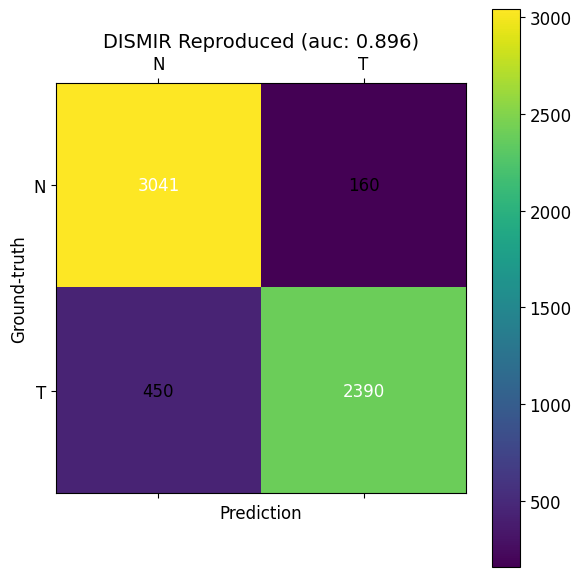

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, auc, roc_curve
import numpy as np

# Set Matplotlib styling
plt.rcParams.update({
    "font.size": 12,
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "grid.color": "lightgray",
    "grid.linestyle": "-",
})

# Compute confusion matrix
cf_matrix = confusion_matrix(labels, predictions)

# Create the heatmap using Matplotlib
fig, ax = plt.subplots(1, figsize=(6, 6))
cax = ax.matshow(cf_matrix, cmap="viridis")
plt.colorbar(cax)

# Annotate the heatmap
for (i, j), val in np.ndenumerate(cf_matrix):
    ax.text(j, i, f"{val}", ha="center", va="center", color="white" if val > cf_matrix.max() / 2 else "black")

# Set axis labels and tick marks
ax.set_xlabel("Prediction", fontsize=12)
ax.set_ylabel("Ground-truth", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(["N", "T"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["N", "T"])

# Compute ROC and AUC
fpr, tpr, thresholds = roc_curve(labels, predictions)
auc_val = auc(fpr, tpr)

# Set title with AUC value
ax.set_title(f"DISMIR Reproduced (auc: {auc_val:.3f})", fontsize=14)

# Show plot
plt.tight_layout()
plt.show()
